In [1]:
import numpy as np
import pandas as pd

import simulator
import generator
import eval

import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance,chi2,skew, kurtosis,energy_distance
from scipy.spatial.distance import cdist, pdist

In [2]:
import warnings
warnings.simplefilter("ignore", category=FutureWarning)

## Ground Truth Series

In [3]:
# period
start_date = "2002-01-01"
end_date = "2025-01-01"

# universe
tickers = {
    "EUR/USD": "EURUSD=X"
}

prices = yf.download(
    list(tickers.values()), start=start_date, end=end_date, 
    auto_adjust=False, progress=False)["Close"]
returns = prices.pct_change().dropna()

In [4]:
prices

Ticker,EURUSD=X
Date,
2003-12-01,1.196501
2003-12-02,1.208897
2003-12-03,1.212298
2003-12-04,1.208094
2003-12-05,1.218695
...,...
2024-12-25,1.040258
2024-12-26,1.039955
2024-12-27,1.042318


In [5]:
NSIM        = 100
LEN_SEED    = 25
LEN_FUTURE  = 60
S0          = 100.0
RESAMPLE    = "1D"    # daily bars for S&P 500
LEN_HIST = 252
LOOKBACK = 20

In [6]:
def prices_to_logreturns(p, axis=-1):
    p = np.asarray(p, dtype=float)
    return np.log(p[..., 1:] / p[..., :-1])

def build_seeded_paths_from_prices(
    px_series: pd.Series,
    nsim: int = NSIM,
    len_seed: int = LEN_SEED,
    len_future: int = LEN_FUTURE,
    resample_rule: str = RESAMPLE,
    s0: float = S0,
    start_idx: int | None = None,
):
    """
    From a price Series -> resample to desired frequency -> nsim non-overlapping blocks
    of length len_seed + len_future + 1 (prices). Normalize each to start at s0.

    Returns:
      dict with:
        paths_price         : (nsim_eff, len_seed+len_future+1)
        seed_prices         : (nsim_eff, len_seed+1)
        seed_logrets        : (nsim_eff, len_seed)
        fut_truth_prices    : (nsim_eff, len_future+1)
        fut_truth_logrets   : (nsim_eff, len_future)
        index_blocks        : list of DatetimeIndex for each path
    """
    px = px_series.copy().dropna().sort_index()
    if resample_rule:
        px = px.resample(resample_rule).last().ffill()

    L = len_seed + len_future + 1
    if start_idx is None:
        start_idx = 0

    total_avail = len(px) - start_idx
    if total_avail < L:
        raise ValueError(f"Not enough points to extract one block: have {total_avail}, need {L}.")

    nsim_eff = min(nsim, total_avail // L)

    blocks, index_blocks = [], []
    for i in range(nsim_eff):
        a = start_idx + i * L
        b = a + L
        seg = px.iloc[a:b]
        blocks.append(seg.to_numpy())
        index_blocks.append(seg.index)

    paths_price = np.stack(blocks, axis=0)  # (nsim_eff, L)

    scales = s0 / paths_price[:, :1]
    paths_price = paths_price * scales

    seed_prices        = paths_price[:, :len_seed+1]
    fut_truth_prices   = paths_price[:, len_seed:]
    seed_logrets       = prices_to_logreturns(seed_prices)
    fut_truth_logrets  = prices_to_logreturns(fut_truth_prices)

    return {
        "paths_price": paths_price,
        "seed_prices": seed_prices,
        "seed_logrets": seed_logrets,
        "fut_truth_prices": fut_truth_prices,
        "fut_truth_logrets": fut_truth_logrets,
        "index_blocks": index_blocks,
        "nsim_eff": nsim_eff,
    }

spx = prices.squeeze()
if isinstance(spx, pd.DataFrame):
    spx = spx.iloc[:, 0]

pack = build_seeded_paths_from_prices(spx)

seed_prices   = pack["seed_prices"]         # (nsim_eff, LEN_SEED+1)
seed_logrets  = pack["seed_logrets"]        # (nsim_eff, LEN_SEED)
fut_prices    = pack["fut_truth_prices"]    # (nsim_eff, LEN_FUTURE+1)
fut_logrets   = pack["fut_truth_logrets"]   # (nsim_eff, LEN_FUTURE)
nsim_eff      = pack["nsim_eff"]

print("nsim_eff:", nsim_eff)
print(seed_prices.shape, seed_logrets.shape, fut_prices.shape, fut_logrets.shape)

nsim_eff: 89
(89, 26) (89, 25) (89, 61) (89, 60)


In [7]:
NSIM        = nsim_eff

## Generate Series with Different Generators

In [8]:
gen_logret = dict()
gen_price = dict()

In [9]:
library_paths = [np.concatenate([seed_logrets[i], fut_logrets[i]]) for i in range(NSIM)]

gen_bs = generator.BootstrapPathwise(
    lookback=LOOKBACK, sig_level=2, forward=5, dt=1, k=10,
    neighbor_weighting="softmax", random_state=42
).fit_logrets(library_paths)

gen_logret['hist'] = seed_logrets                              # shape (NSIM, LEN_SEED)
gen_price['hist']  = seed_prices[:, 1:]                        # (NSIM, LEN_SEED)
gen_logret['bootstrap'] = np.vstack([
    gen_bs.generate_logrets(
        seed_path=seed_logrets[i],            # (LEN_SEED,)
        n_total_steps=LEN_SEED + LEN_FUTURE,  # returns back length LEN_FUTURE
        return_full_path=False
    )
    for i in range(NSIM)
])  # shape: (NSIM, LEN_FUTURE)

gen_price['bootstrap'] = np.vstack([
    generator.logrets_to_prices(
        gen_logret['bootstrap'][i],
        s0=seed_prices[i, -1]
    )[1:]
    for i in range(NSIM)
])  # shape: (NSIM, LEN_FUTURE)

gen_logret['truth'] = fut_logrets          # (NSIM, LEN_FUTURE)
gen_price['truth']  = fut_prices[:, 1:]    # (NSIM, LEN_FUTURE)

100%|███████████████████████████████████████████████████████████████████████████████| 60/60 [00:00<00:00, 14969.86it/s]


In [10]:
gen_hb = generator.HybridKRRBootstrap(
    lookback=LOOKBACK, sig_level=2, dt=1, k=10, lam=1,
    neighbor_weighting="softmax", random_state=42
).fit_logrets(library_paths)

gen_logret['hybrid'] = np.vstack([
    gen_hb.generate_logrets(
        seed_path=seed_logrets[i],               # (LEN_SEED,)
        n_total_steps=LEN_SEED + LEN_FUTURE,     # -> returns length LEN_FUTURE
        return_full_path=False
    )
    for i in range(NSIM)
])  # shape: (NSIM, LEN_FUTURE)

gen_price['hybrid'] = np.vstack([
    generator.logrets_to_prices(gen_logret['hybrid'][i], s0=seed_prices[i, -1])[1:]
    for i in range(NSIM)
])  # shape: (NSIM, LEN_FUTURE)

100%|████████████████████████████████████████████████████████████████████████████████| 65/65 [00:00<00:00, 2793.57it/s]


In [11]:
gen_krr = generator.KRRSignature(
    lookback=LOOKBACK, sig_level=2, dt=1, lam_mu=1, lam_sig=1, random_state=42
).fit_logrets(library_paths)

gen_logret['krr'] = np.vstack([
    gen_krr.generate_logrets(
        seed_path=seed_logrets[i],                 # (LEN_SEED,)
        n_total_steps=LEN_SEED + LEN_FUTURE,       # -> returns length LEN_FUTURE
        stochastic=True,                           # mean path if False
        return_full_path=False
    )
    for i in range(NSIM)
])  # shape: (NSIM, LEN_FUTURE)

gen_price['krr'] = np.vstack([
    generator.logrets_to_prices(gen_logret['krr'][i], s0=seed_prices[i, -1])[1:]
    for i in range(NSIM)
])  # shape: (NSIM, LEN_FUTURE)

In [12]:
arima_train = np.concatenate(library_paths)  # 85 * NSIM returns

gen_arima = generator.ARIMAGen(order=(1,0,1), trend='c', random_state=42).fit_logrets(arima_train)

gen_logret['arima'] = np.vstack([
    gen_arima.generate_logrets(n_steps=LEN_FUTURE)
    for _ in range(NSIM)
])  # shape: (NSIM, LEN_FUTURE)

gen_price['arima'] = np.vstack([
    generator.logrets_to_prices(gen_logret['arima'][i], s0=seed_prices[i, -1])[1:]
    for i in range(NSIM)
])  # shape: (NSIM, LEN_FUTURE)

In [13]:
garch_train = np.concatenate(library_paths)  # length = (LEN_SEED+LEN_FUTURE) * NSIM

gen_garch = generator.GARCHGen(p=1, q=1, dist='t', random_state=42, scale='auto').fit_logrets(garch_train)

gen_logret['garch'] = np.vstack([
    gen_garch.generate_logrets(n_steps=LEN_FUTURE, seed_returns=seed_logrets[i])
    for i in range(NSIM)
])  # (NSIM, LEN_FUTURE)

gen_price['garch'] = np.vstack([
    generator.logrets_to_prices(gen_logret['garch'][i], s0=seed_prices[i, -1])[1:]
    for i in range(NSIM)
])  # (NSIM, LEN_FUTURE)

## Distribution Comparison

Generating method: bootstrap


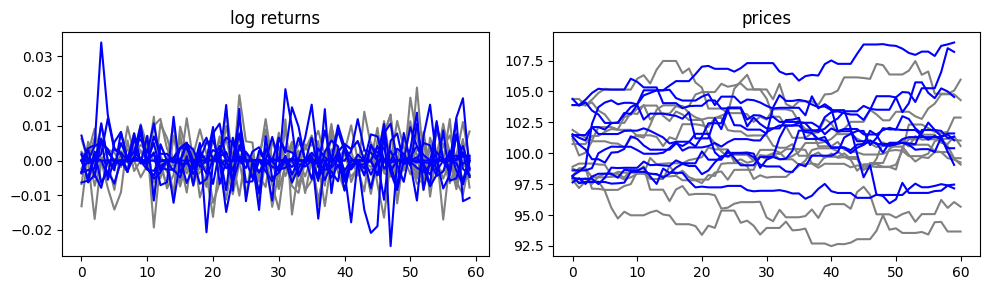

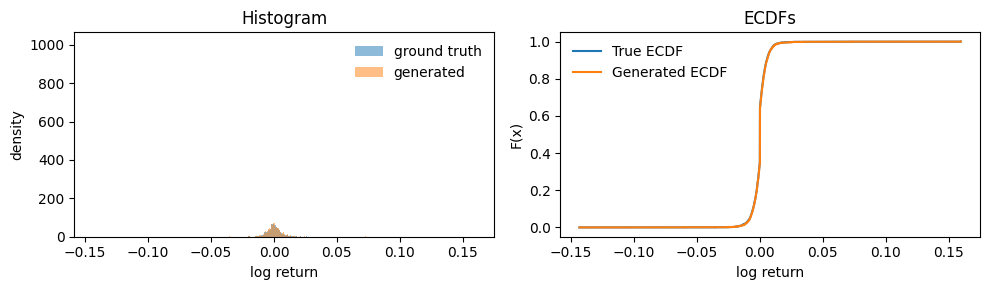

In [14]:
NSHOW = 10
METHOD = 'bootstrap'

print("Generating method:", METHOD)
eval.plot_series_compare(fut_logrets[:NSHOW], fut_prices[:NSHOW], gen_logret[METHOD][:NSHOW], gen_price[METHOD][:NSHOW])
eval.plot_dist_compare(fut_logrets, gen_logret[METHOD])

Generating method: hybrid


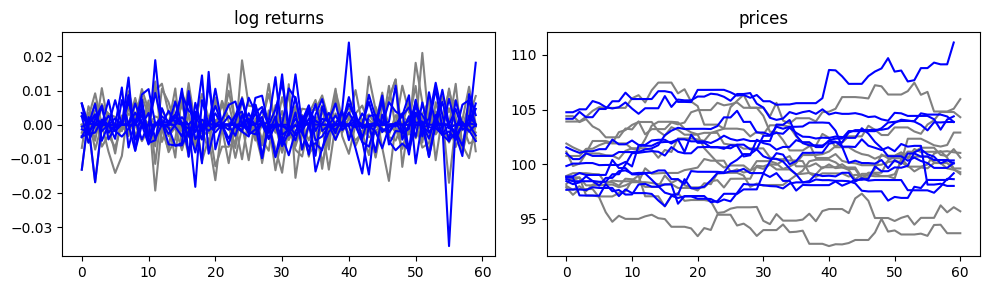

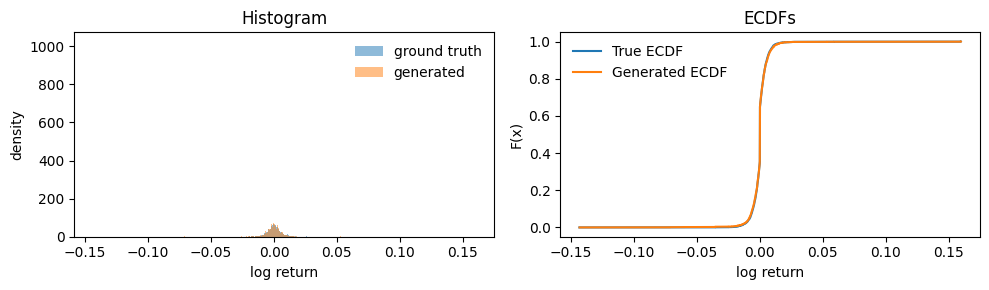

In [15]:
NSHOW = 10
METHOD = 'hybrid'

print("Generating method:", METHOD)
eval.plot_series_compare(fut_logrets[:NSHOW], fut_prices[:NSHOW], gen_logret[METHOD][:NSHOW], gen_price[METHOD][:NSHOW])
eval.plot_dist_compare(fut_logrets, gen_logret[METHOD])

Generating method: krr


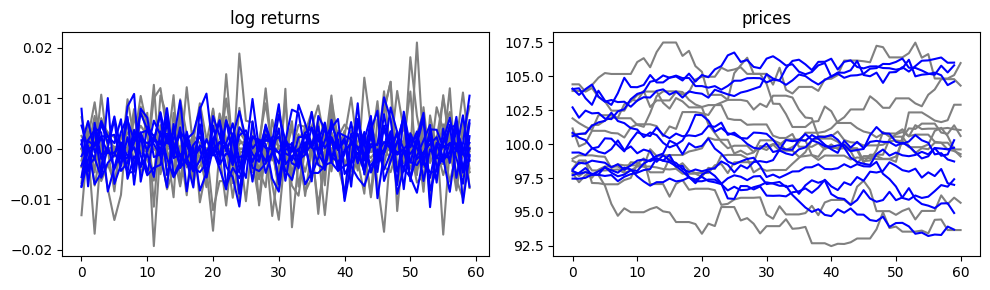

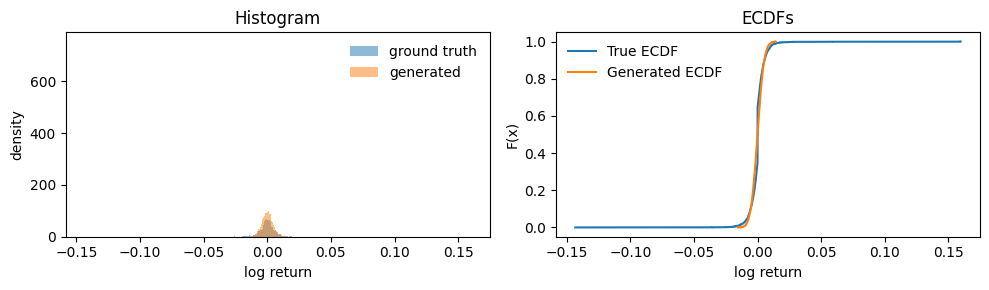

In [16]:
NSHOW = 10
METHOD = 'krr'

print("Generating method:", METHOD)
eval.plot_series_compare(fut_logrets[:NSHOW], fut_prices[:NSHOW], gen_logret[METHOD][:NSHOW], gen_price[METHOD][:NSHOW])
eval.plot_dist_compare(fut_logrets, gen_logret[METHOD])

Generating method: arima


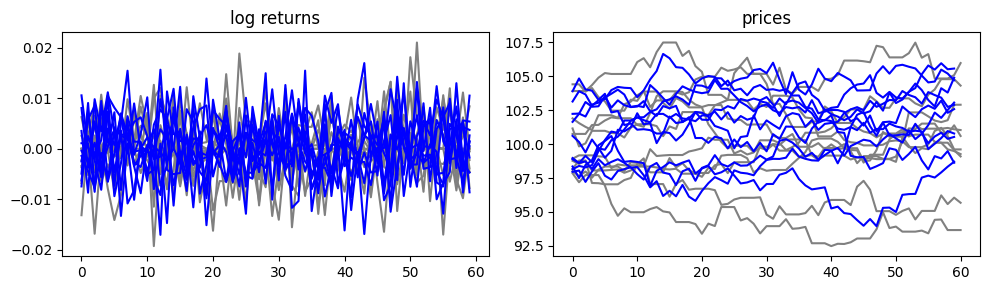

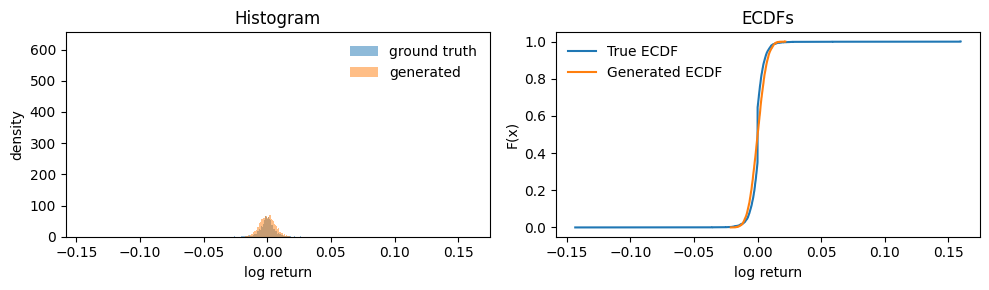

In [17]:
NSHOW = 10
METHOD = 'arima'

print("Generating method:", METHOD)
eval.plot_series_compare(fut_logrets[:NSHOW], fut_prices[:NSHOW], gen_logret[METHOD][:NSHOW], gen_price[METHOD][:NSHOW])
eval.plot_dist_compare(fut_logrets, gen_logret[METHOD])

Generating method: garch


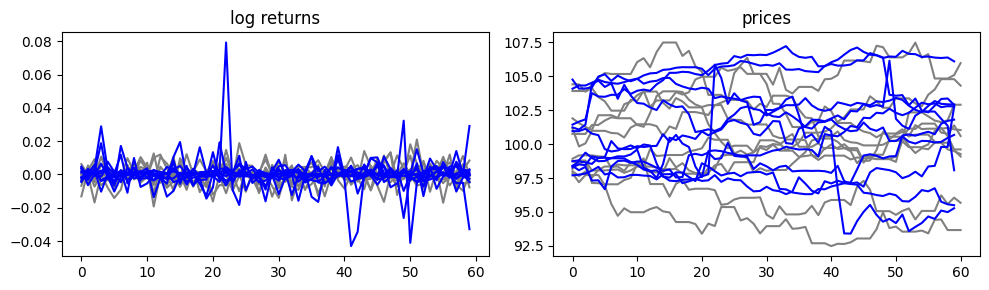

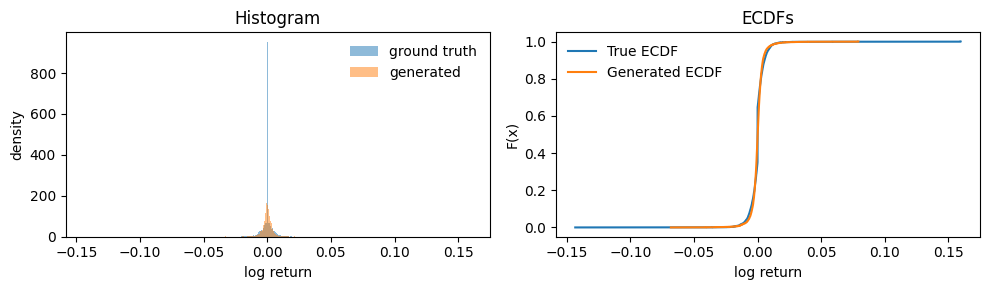

In [18]:
NSHOW = 10
METHOD = 'garch'

print("Generating method:", METHOD)
eval.plot_series_compare(fut_logrets[:NSHOW], fut_prices[:NSHOW], gen_logret[METHOD][:NSHOW], gen_price[METHOD][:NSHOW])
eval.plot_dist_compare(fut_logrets, gen_logret[METHOD])

## Signature MMD

In [19]:
mmd = dict()
methods = ['bootstrap', 'krr','hybrid','arima','garch']
for method in methods:
    mmd[method] = eval.mmd_signature_linear(
        np.arange(LEN_FUTURE), gen_price[method], fut_prices[:,1:], window_size=5, sig_level=2)

In [20]:
pd.DataFrame(pd.Series(mmd))

,0
bootstrap,0.023895
krr,0.055073
hybrid,0.098339
arima,0.008970
garch,0.011115


In [21]:
def evaluate_models(fut_prices, fut_logrets, gen_price, gen_logret, use="logret"):
    """
    Compare generated paths to GBM ground truth using your moment_check().

    Parameters
    ----------
    fut_prices   : (NSIM, LEN_FUTURE+1) GBM price paths
    fut_logrets  : (NSIM, LEN_FUTURE)   GBM log-returns
    gen_price    : dict[name -> (NSIM, LEN_FUTURE)]   generated prices
    gen_logret   : dict[name -> (NSIM, LEN_FUTURE)]   generated log-returns
    use          : "logret" or "price"  (which domain to evaluate in)

    Returns
    -------
    results : dict[name -> dict with metrics]
    """
    results = {}

    if use == "logret":
        gt = fut_logrets                           # (NSIM, T)
        model_panels = gen_logret                  # dict of (NSIM, T)
    elif use == "price":
        # Align shapes to (NSIM, T): drop the first column from fut_prices
        gt = fut_prices[:, 1:]                     # (NSIM, T)
        model_panels = gen_price
    else:
        raise ValueError("use must be 'logret' or 'price'")

    for name, gen in model_panels.items():
        print(f"\n=== Evaluating {name} on {use}s ===")
        mmd_lin, mmd_rbf, sigma_used, pvals = moment_check(gt, gen)
        results[name] = {
            "domain": use,
            "mmd_linear": float(mmd_lin),
            "mmd_rbf": float(mmd_rbf),
            "rbf_sigma": float(sigma_used),
            "ks_pvals": list(map(float, pvals)),   # [Mean, Var, Skew, Kurt] order
            "n_paths_gt": int(gt.shape[0]),
            "n_paths_gen": int(gen.shape[0]),
            "horizon": int(gen.shape[1]),
        }
    return results

In [22]:
def moment_check(path1,path2):
    stats1 = path_stats(path1)
    stats2   = path_stats(path2)
    
    labels = ["Mean", "Variance", "Skewness", "Kurtosis"]
    df_train = pd.DataFrame(stats1, columns=labels)
    df_train["Source"] = "Training"
    df_gen = pd.DataFrame(stats2, columns=labels)
    df_gen["Source"] = "Generated"
    df_all = pd.concat([df_train, df_gen], ignore_index=True)
    df_all = df_all.replace([np.inf, -np.inf], np.nan).dropna()
    sns.pairplot(df_all, hue="Source", diag_kind="kde", corner=True,
                 plot_kws=dict(alpha=0.5, s=20))
    plt.suptitle("Comparison of per-path statistics (Training vs Generated)", y=1.02)
    plt.show()
    p_val = []
    for i, name in enumerate(labels):
        stat, pval = ks_2samp(stats1[:, i], stats2[:, i])
        print(f"KS test on {name:>8}: statistic={stat:.3f}, p-value={pval:.3f}")
        p_val.append(pval)
    mean_train = np.mean(stats1, axis=0)
    mean_gen = np.mean(stats2, axis=0)

    mmd_sq = np.sum((mean_train - mean_gen)**2)
    print(f'Linear kernel MMD^2: {mmd_sq:.4f}')
    mmd_val, sigma_used = compute_mmd(stats1, stats2)
    print(f"RBF kernel MMD^2 = {mmd_val:.4e},  sigma = {sigma_used:.3f}")
    return mmd_sq, mmd_val, sigma_used,p_val

In [23]:
def path_stats(paths,logrtn=False):
    """Compute per-path mean, variance, skew, and kurtosis of log-returns."""
    stats = []
    for p in paths:
        if logrtn:
            r = np.diff(np.log(p))  # log-returns
        else:
            r = p
        stats.append([
            np.mean(r),
            np.var(r, ddof=1),
            skew(r, bias=False),
            kurtosis(r, fisher=True, bias=False)  # excess kurtosis
        ])
    return np.array(stats)

In [24]:
def compute_mmd(X, Y, kernel='rbf', sigma=None):
    X = np.asarray(X, float)
    Y = np.asarray(Y, float)
    if X.ndim == 1: X = X[:, None]
    if Y.ndim == 1: Y = Y[:, None]
    
    # pairwise squared distances
    XX = cdist(X, X, 'sqeuclidean')
    YY = cdist(Y, Y, 'sqeuclidean')
    XY = cdist(X, Y, 'sqeuclidean')
    
    # bandwidth heuristic
    if sigma is None:
        pairwise_dists = np.concatenate([XX.flatten(), YY.flatten(), XY.flatten()])
        sigma = np.sqrt(0.5 * np.median(pairwise_dists[pairwise_dists > 0]))
    
    # kernel matrices
    Kxx = np.exp(-XX / (2 * sigma**2))
    Kyy = np.exp(-YY / (2 * sigma**2))
    Kxy = np.exp(-XY / (2 * sigma**2))
    
    n, m = len(X), len(Y)
    mmd2 = (
        (Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
        + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
        - 2 * Kxy.mean()
    )
    return mmd2, sigma


=== Evaluating hist on logrets ===


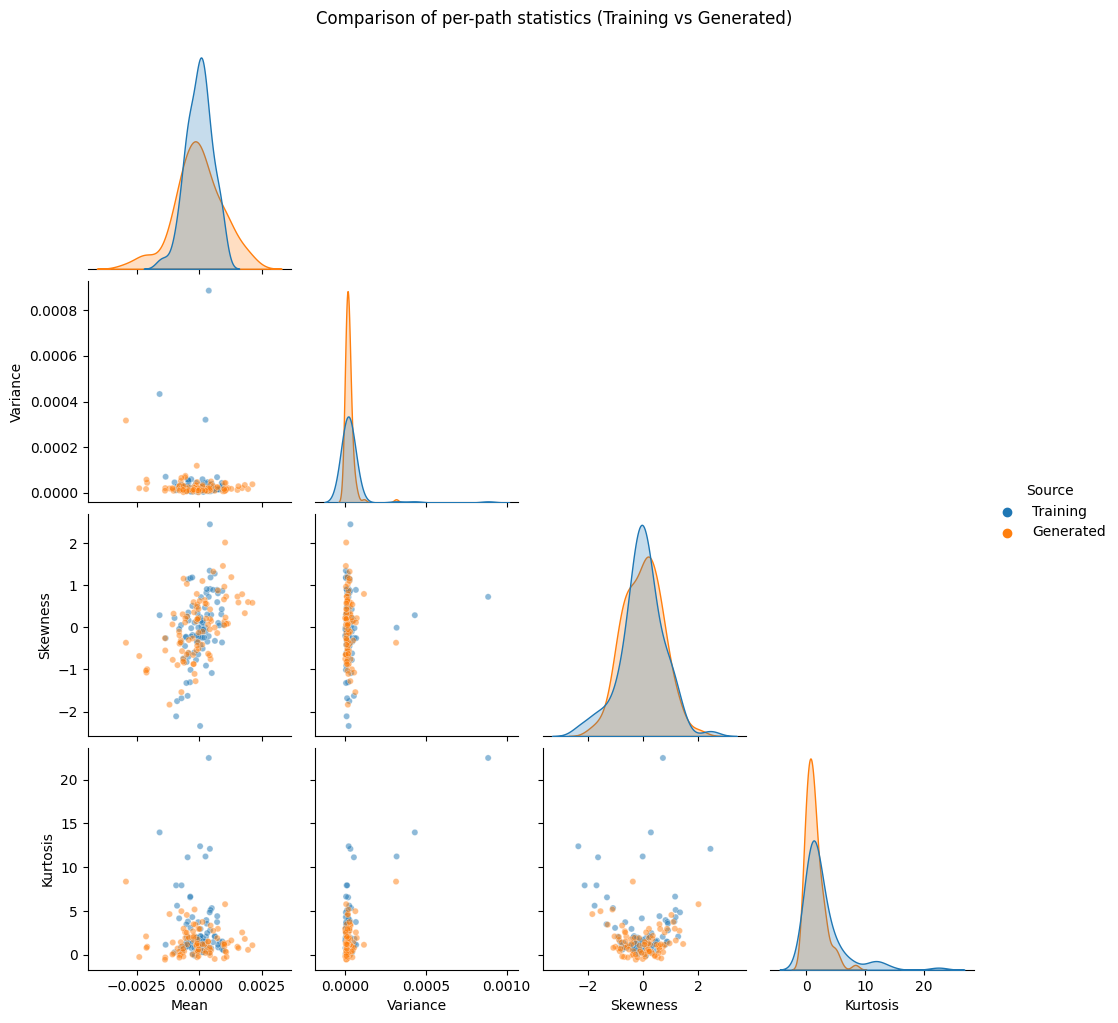

KS test on     Mean: statistic=0.180, p-value=0.113
KS test on Variance: statistic=0.090, p-value=0.868
KS test on Skewness: statistic=0.101, p-value=0.756
KS test on Kurtosis: statistic=0.225, p-value=0.022
Linear kernel MMD^2: 1.9129
RBF kernel MMD^2 = 1.4045e-02,  sigma = 1.131

=== Evaluating bootstrap on logrets ===


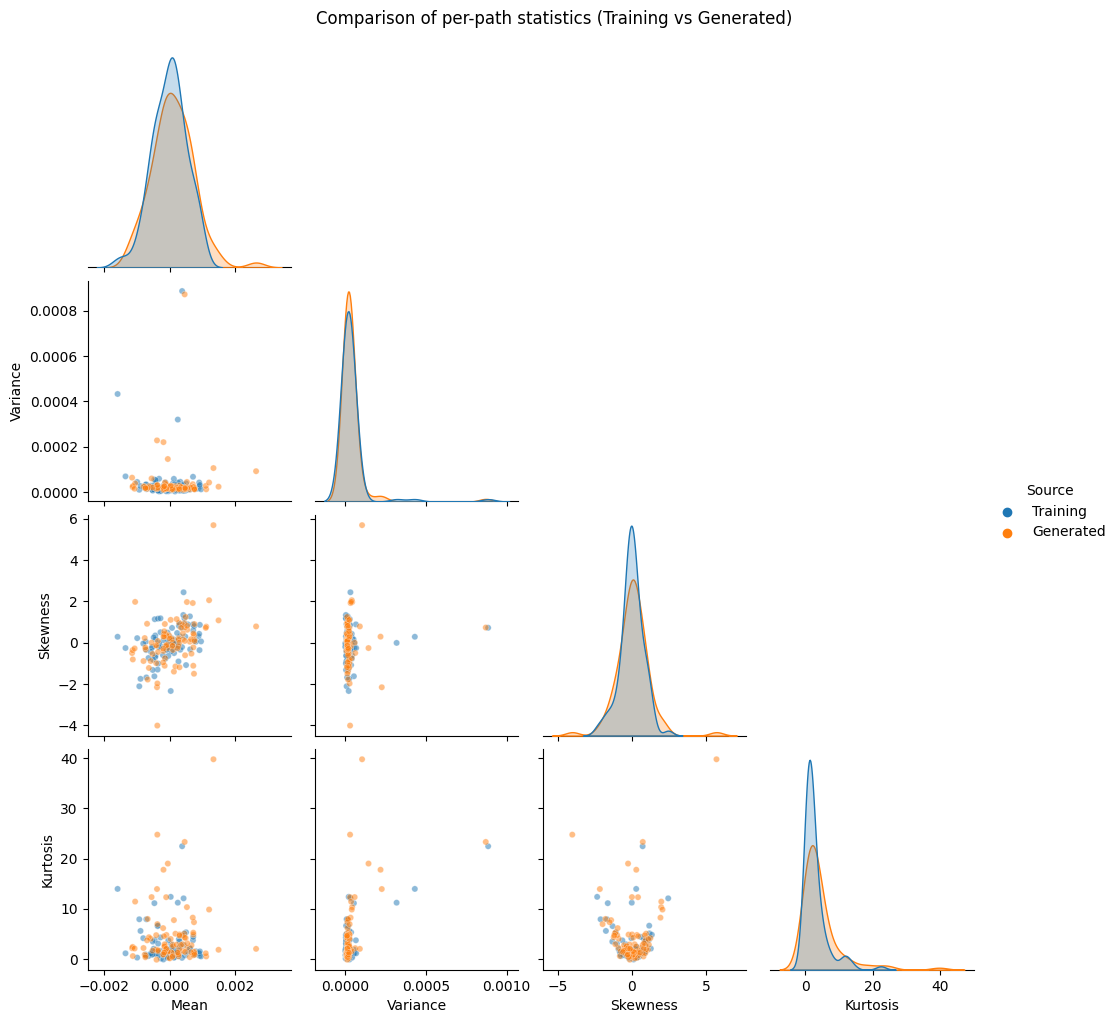

KS test on     Mean: statistic=0.124, p-value=0.507
KS test on Variance: statistic=0.281, p-value=0.002
KS test on Skewness: statistic=0.101, p-value=0.756
KS test on Kurtosis: statistic=0.225, p-value=0.022
Linear kernel MMD^2: 2.8061
RBF kernel MMD^2 = 2.1006e-02,  sigma = 1.603

=== Evaluating truth on logrets ===


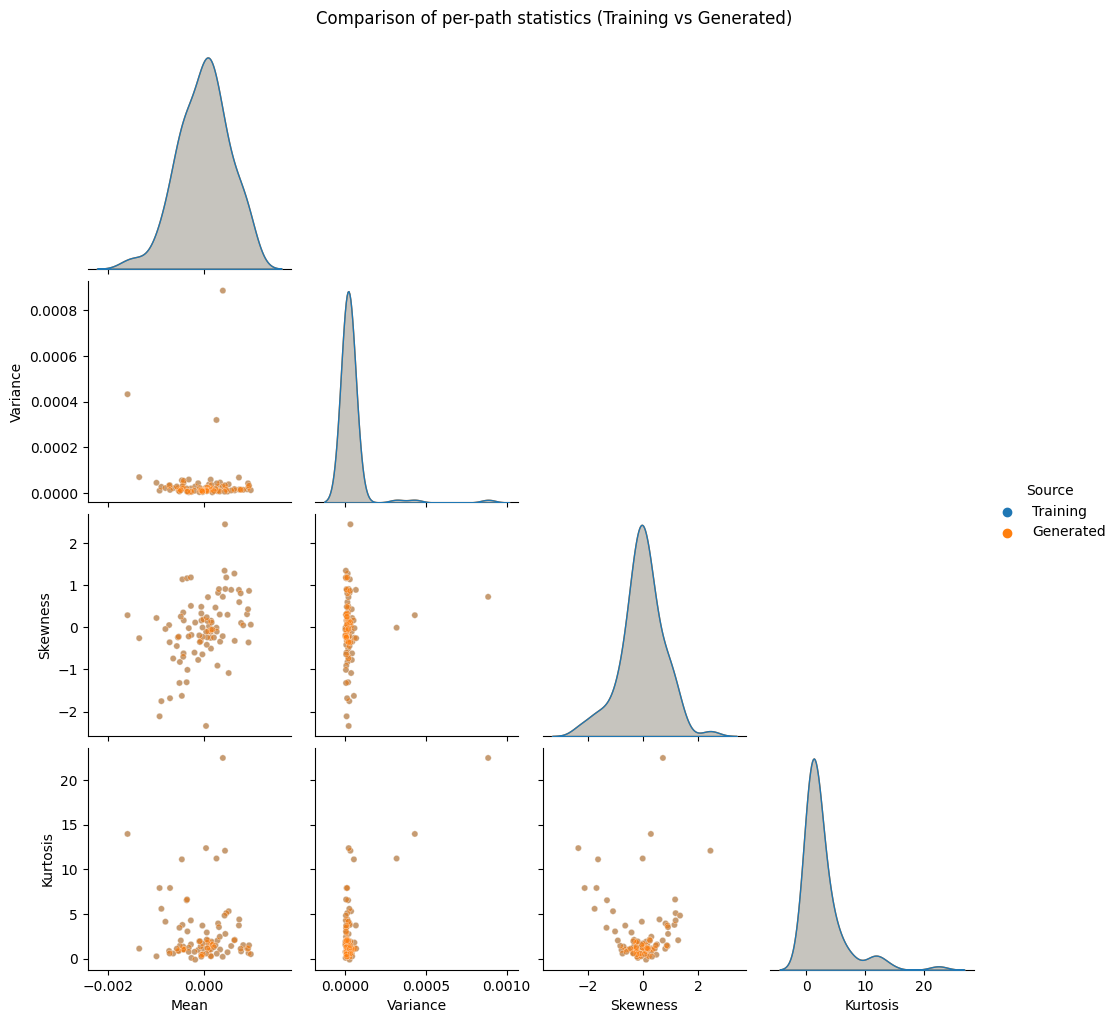

KS test on     Mean: statistic=0.000, p-value=1.000
KS test on Variance: statistic=0.000, p-value=1.000
KS test on Skewness: statistic=0.000, p-value=1.000
KS test on Kurtosis: statistic=0.000, p-value=1.000
Linear kernel MMD^2: 0.0000
RBF kernel MMD^2 = -1.3380e-02,  sigma = 1.207

=== Evaluating hybrid on logrets ===


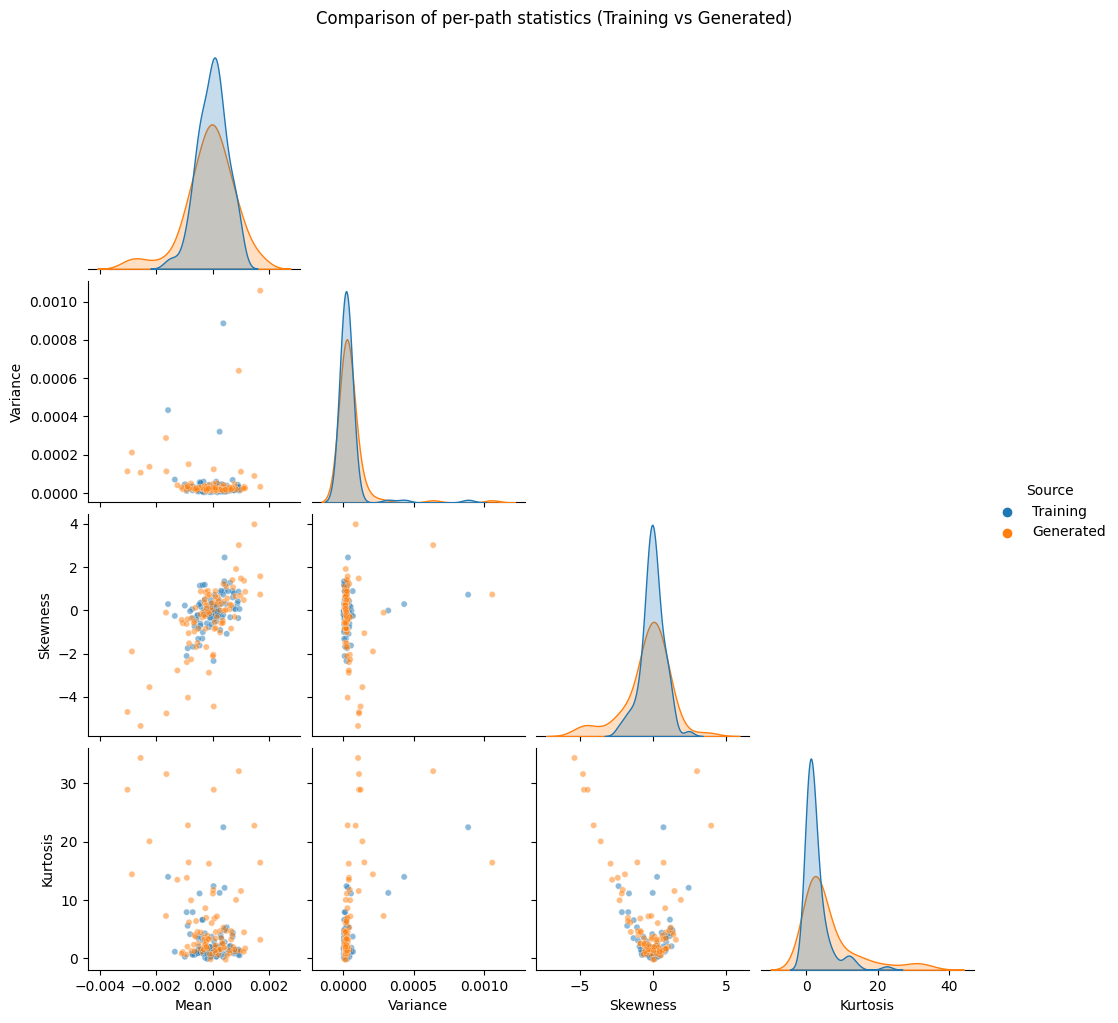

KS test on     Mean: statistic=0.135, p-value=0.395
KS test on Variance: statistic=0.337, p-value=0.000
KS test on Skewness: statistic=0.180, p-value=0.113
KS test on Kurtosis: statistic=0.315, p-value=0.000
Linear kernel MMD^2: 12.6486
RBF kernel MMD^2 = 5.5801e-02,  sigma = 1.915

=== Evaluating krr on logrets ===


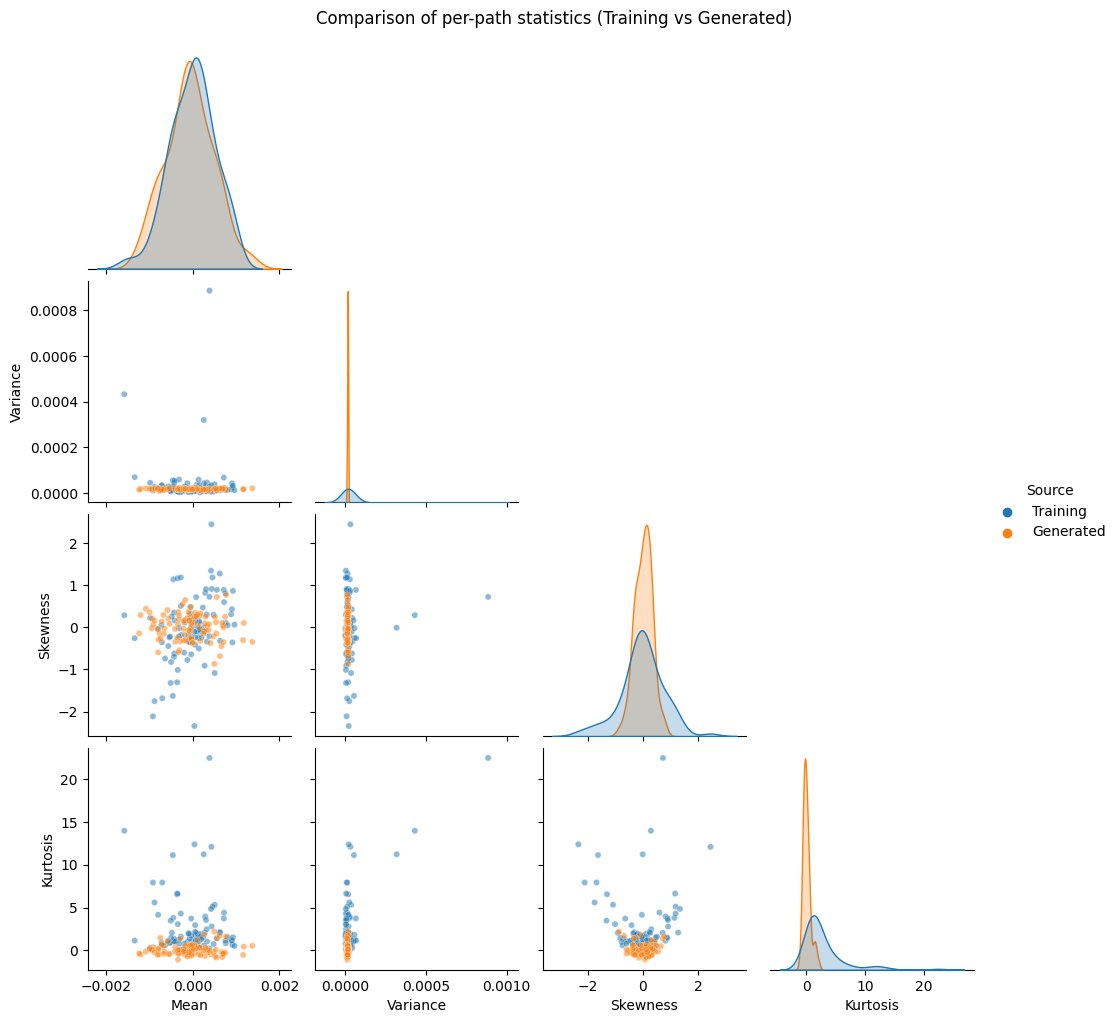

KS test on     Mean: statistic=0.135, p-value=0.395
KS test on Variance: statistic=0.371, p-value=0.000
KS test on Skewness: statistic=0.169, p-value=0.160
KS test on Kurtosis: statistic=0.719, p-value=0.000
Linear kernel MMD^2: 7.4392
RBF kernel MMD^2 = 4.0416e-01,  sigma = 0.843

=== Evaluating arima on logrets ===


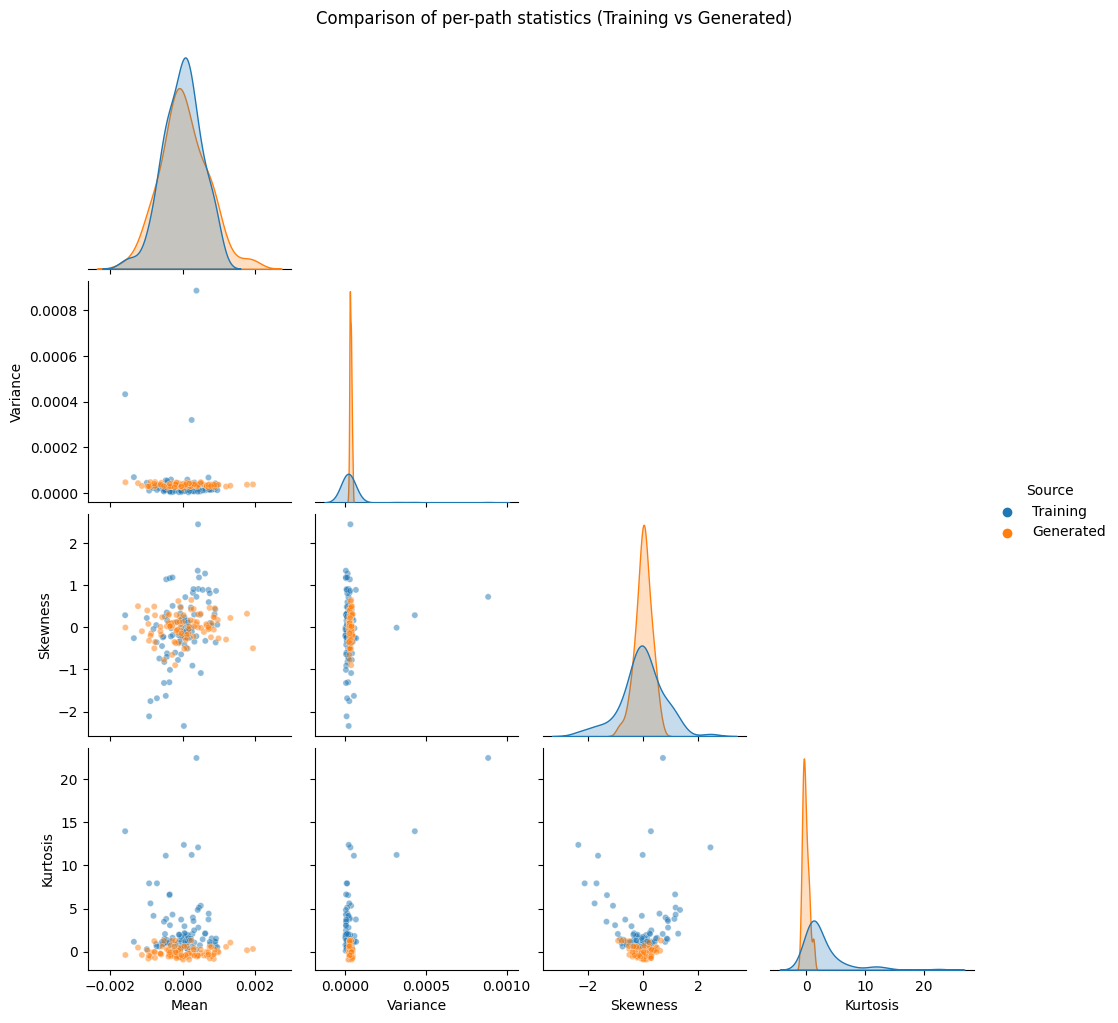

KS test on     Mean: statistic=0.090, p-value=0.868
KS test on Variance: statistic=0.652, p-value=0.000
KS test on Skewness: statistic=0.191, p-value=0.078
KS test on Kurtosis: statistic=0.753, p-value=0.000
Linear kernel MMD^2: 8.3346
RBF kernel MMD^2 = 4.9271e-01,  sigma = 0.840

=== Evaluating garch on logrets ===


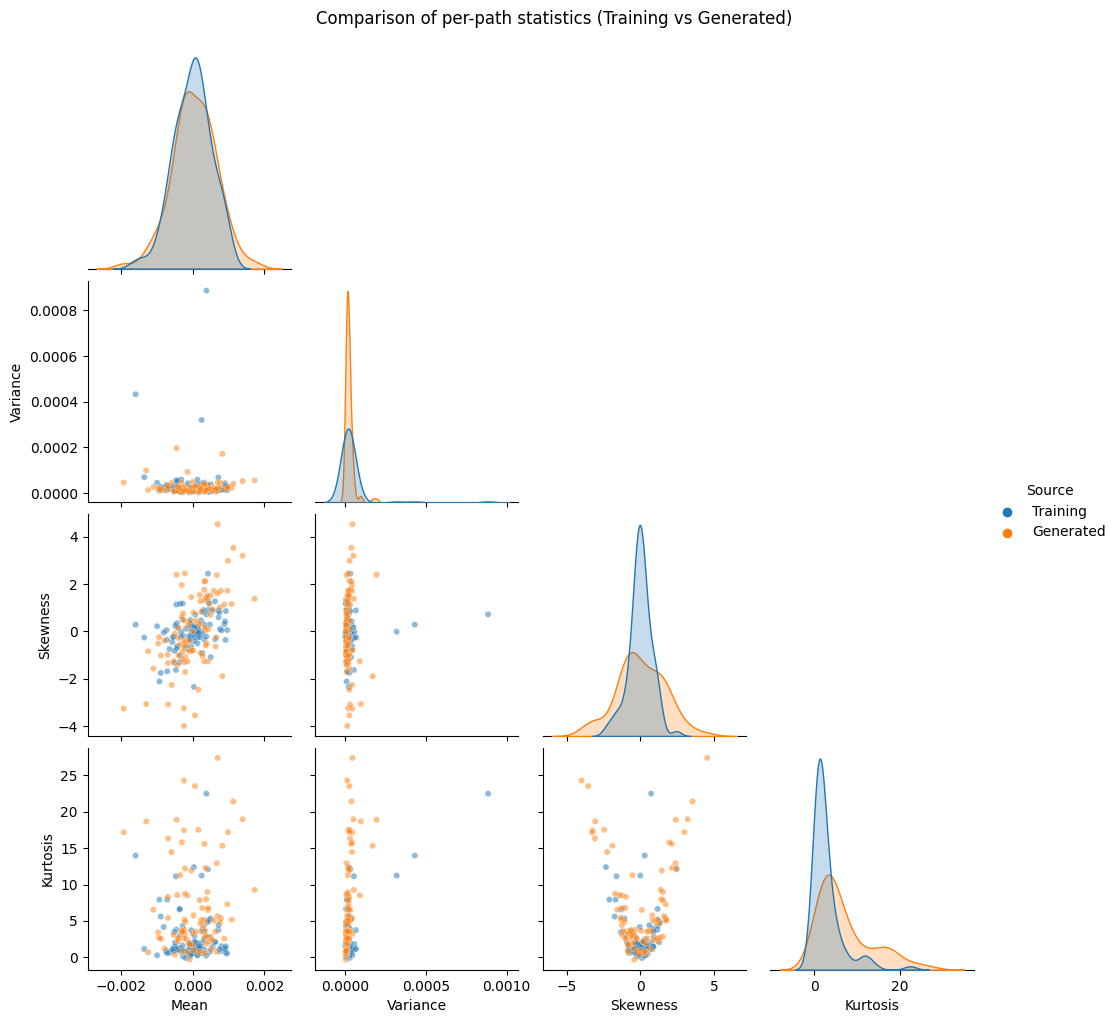

KS test on     Mean: statistic=0.124, p-value=0.507
KS test on Variance: statistic=0.090, p-value=0.868
KS test on Skewness: statistic=0.236, p-value=0.014
KS test on Kurtosis: statistic=0.517, p-value=0.000
Linear kernel MMD^2: 17.6388
RBF kernel MMD^2 = 1.5739e-01,  sigma = 2.320

=== Evaluating hist on prices ===


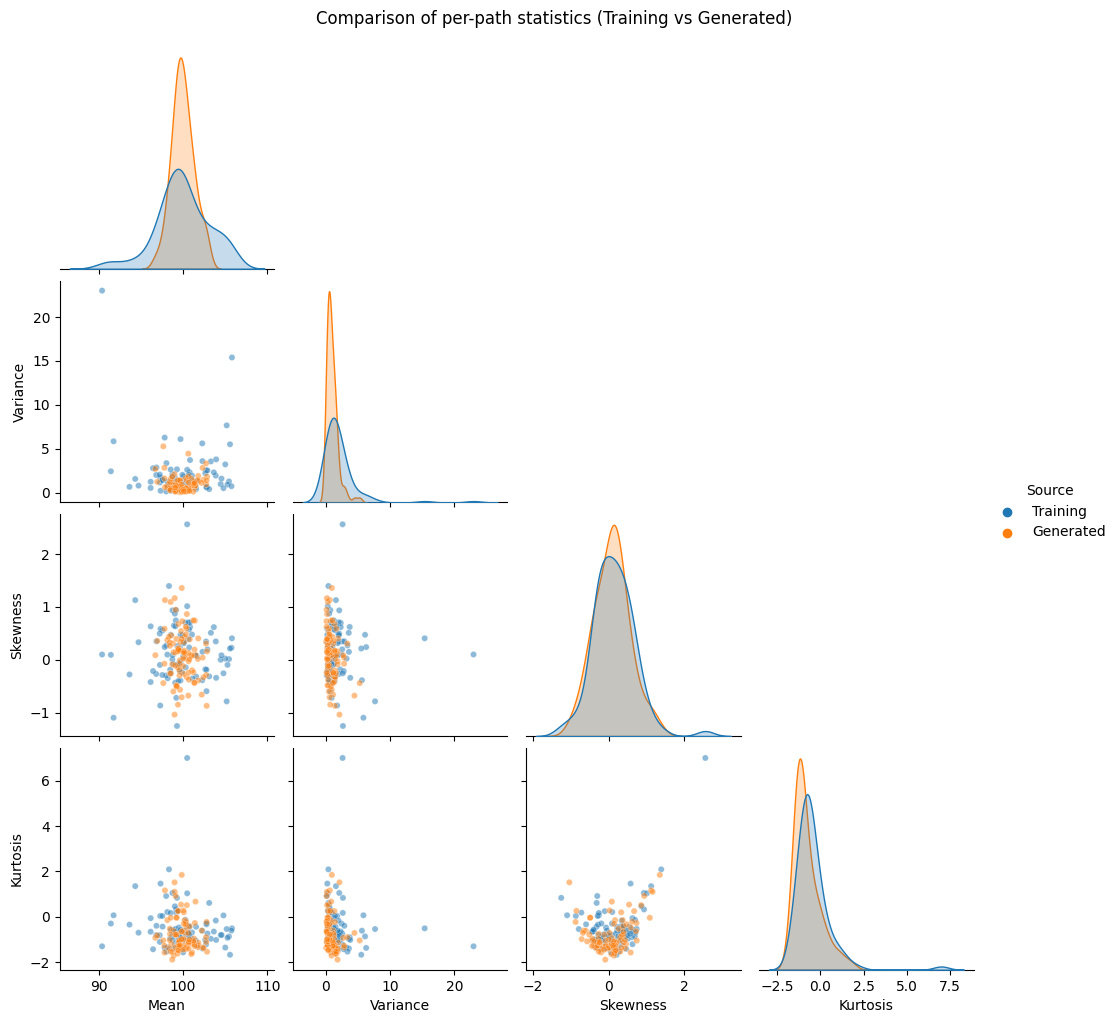

KS test on     Mean: statistic=0.180, p-value=0.113
KS test on Variance: statistic=0.292, p-value=0.001
KS test on Skewness: statistic=0.112, p-value=0.631
KS test on Kurtosis: statistic=0.315, p-value=0.000
Linear kernel MMD^2: 1.4285
RBF kernel MMD^2 = 8.9513e-02,  sigma = 2.022

=== Evaluating bootstrap on prices ===


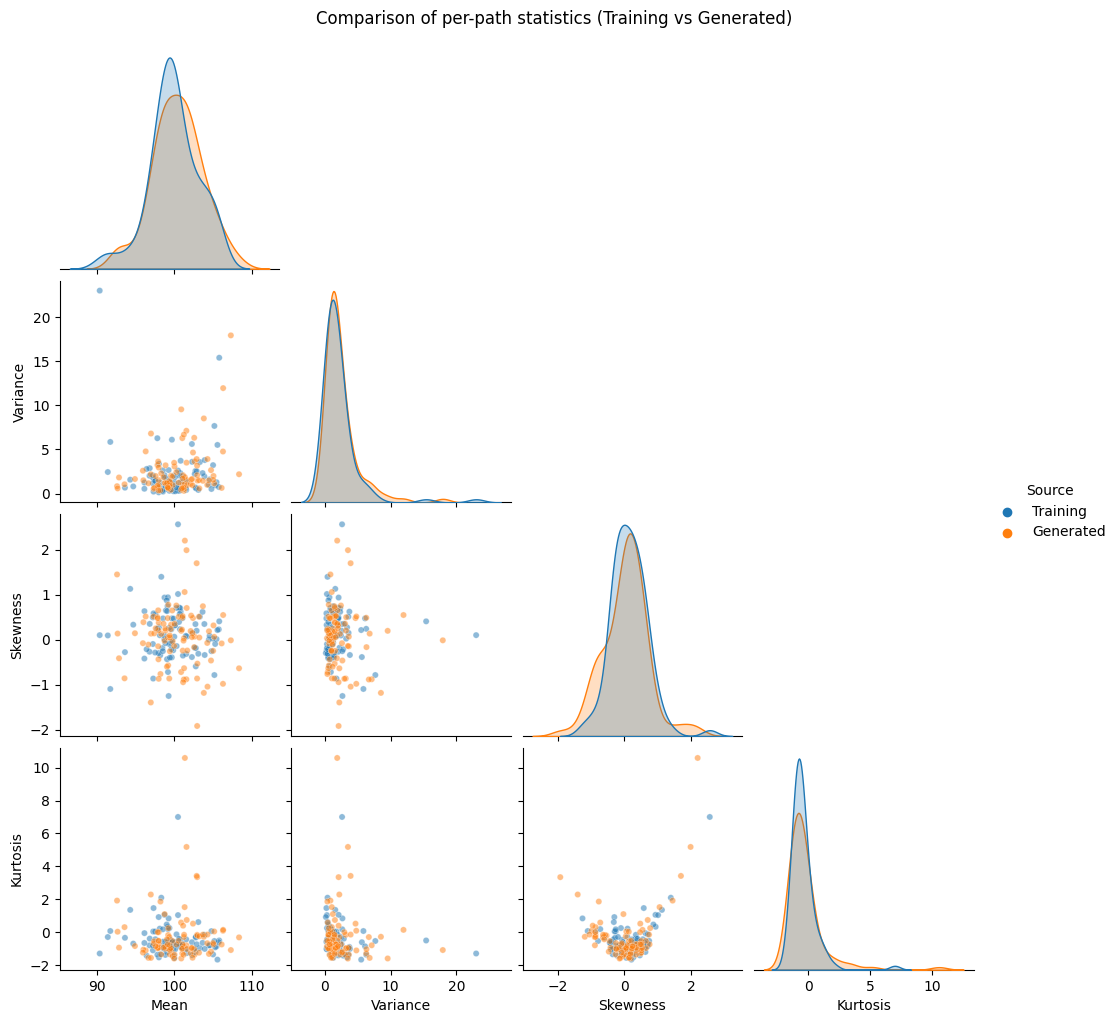

KS test on     Mean: statistic=0.191, p-value=0.078
KS test on Variance: statistic=0.169, p-value=0.160
KS test on Skewness: statistic=0.169, p-value=0.160
KS test on Kurtosis: statistic=0.112, p-value=0.631
Linear kernel MMD^2: 0.3922
RBF kernel MMD^2 = -1.4609e-03,  sigma = 3.072

=== Evaluating truth on prices ===


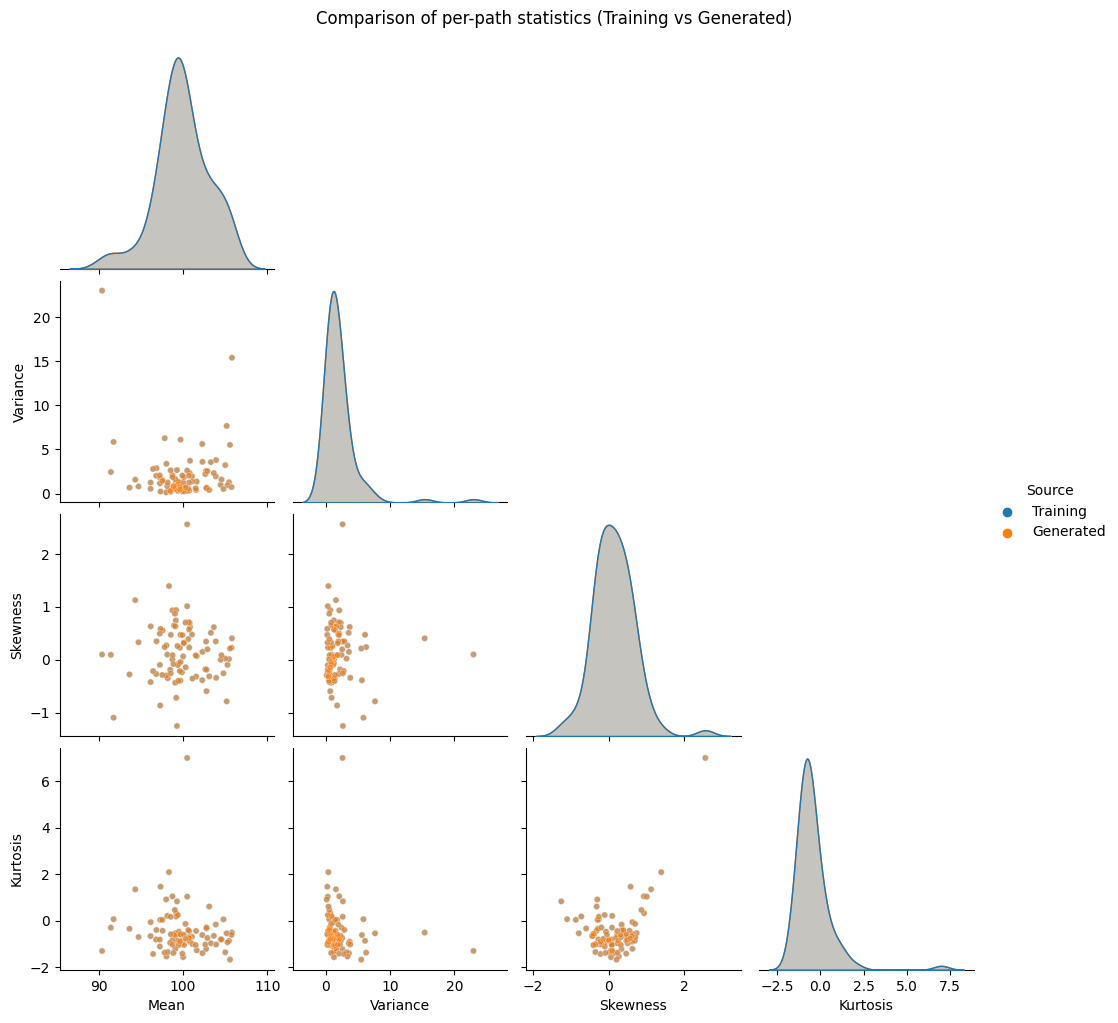

KS test on     Mean: statistic=0.000, p-value=1.000
KS test on Variance: statistic=0.000, p-value=1.000
KS test on Skewness: statistic=0.000, p-value=1.000
KS test on Kurtosis: statistic=0.000, p-value=1.000
Linear kernel MMD^2: 0.0000
RBF kernel MMD^2 = -1.3477e-02,  sigma = 2.769

=== Evaluating hybrid on prices ===


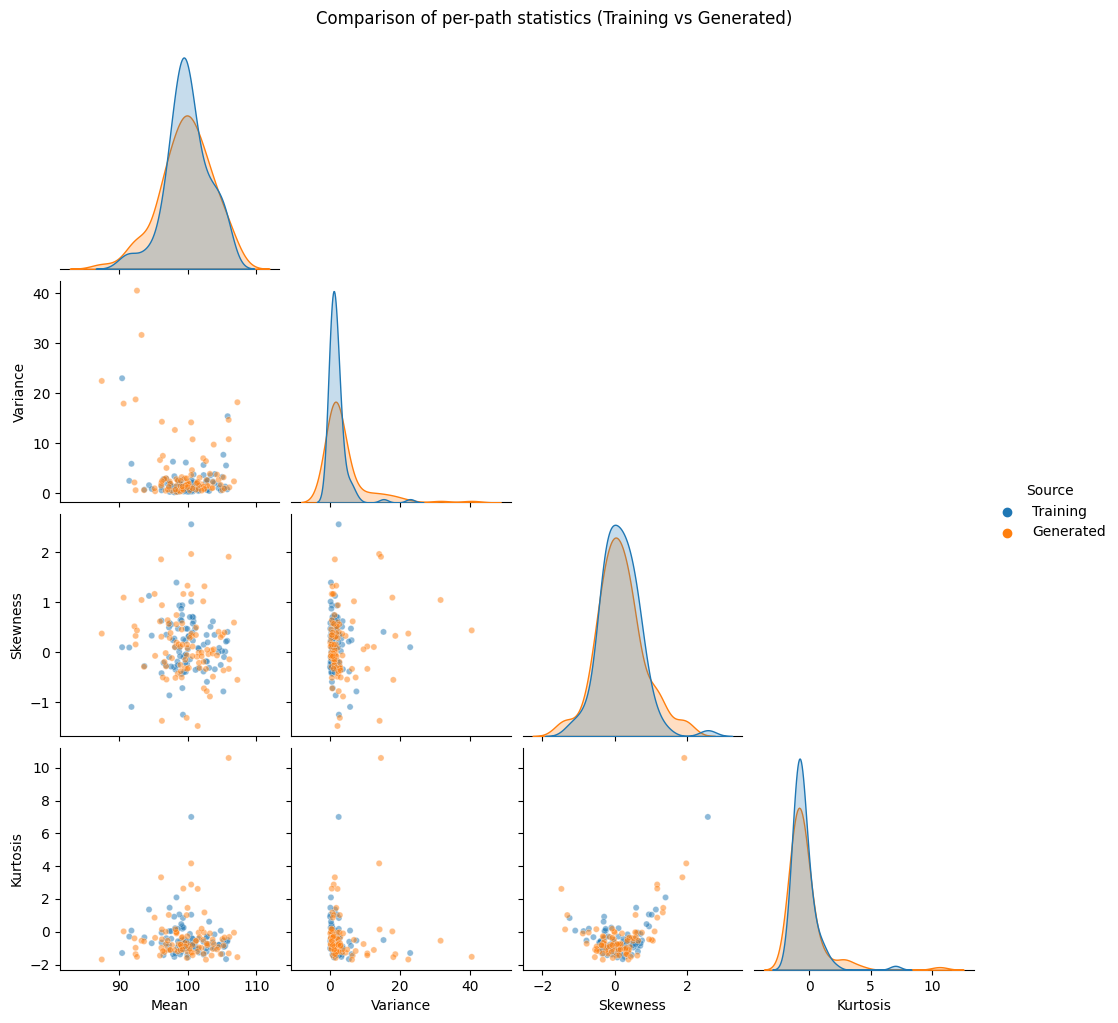

KS test on     Mean: statistic=0.124, p-value=0.507
KS test on Variance: statistic=0.191, p-value=0.078
KS test on Skewness: statistic=0.090, p-value=0.868
KS test on Kurtosis: statistic=0.135, p-value=0.395
Linear kernel MMD^2: 5.0438
RBF kernel MMD^2 = 9.8635e-03,  sigma = 3.281

=== Evaluating krr on prices ===


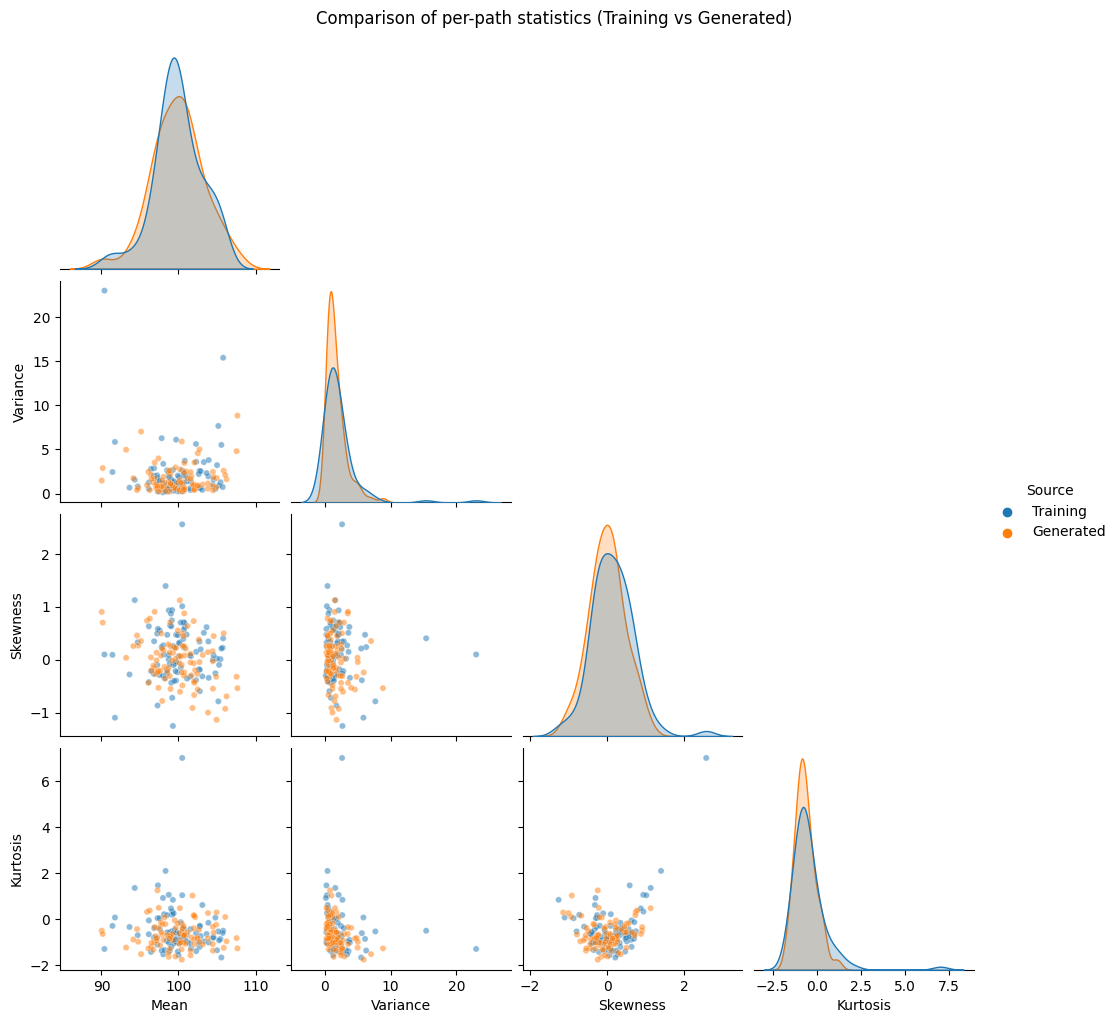

KS test on     Mean: statistic=0.090, p-value=0.868
KS test on Variance: statistic=0.112, p-value=0.631
KS test on Skewness: statistic=0.157, p-value=0.222
KS test on Kurtosis: statistic=0.090, p-value=0.868
Linear kernel MMD^2: 0.2540
RBF kernel MMD^2 = -7.8183e-03,  sigma = 2.745

=== Evaluating arima on prices ===


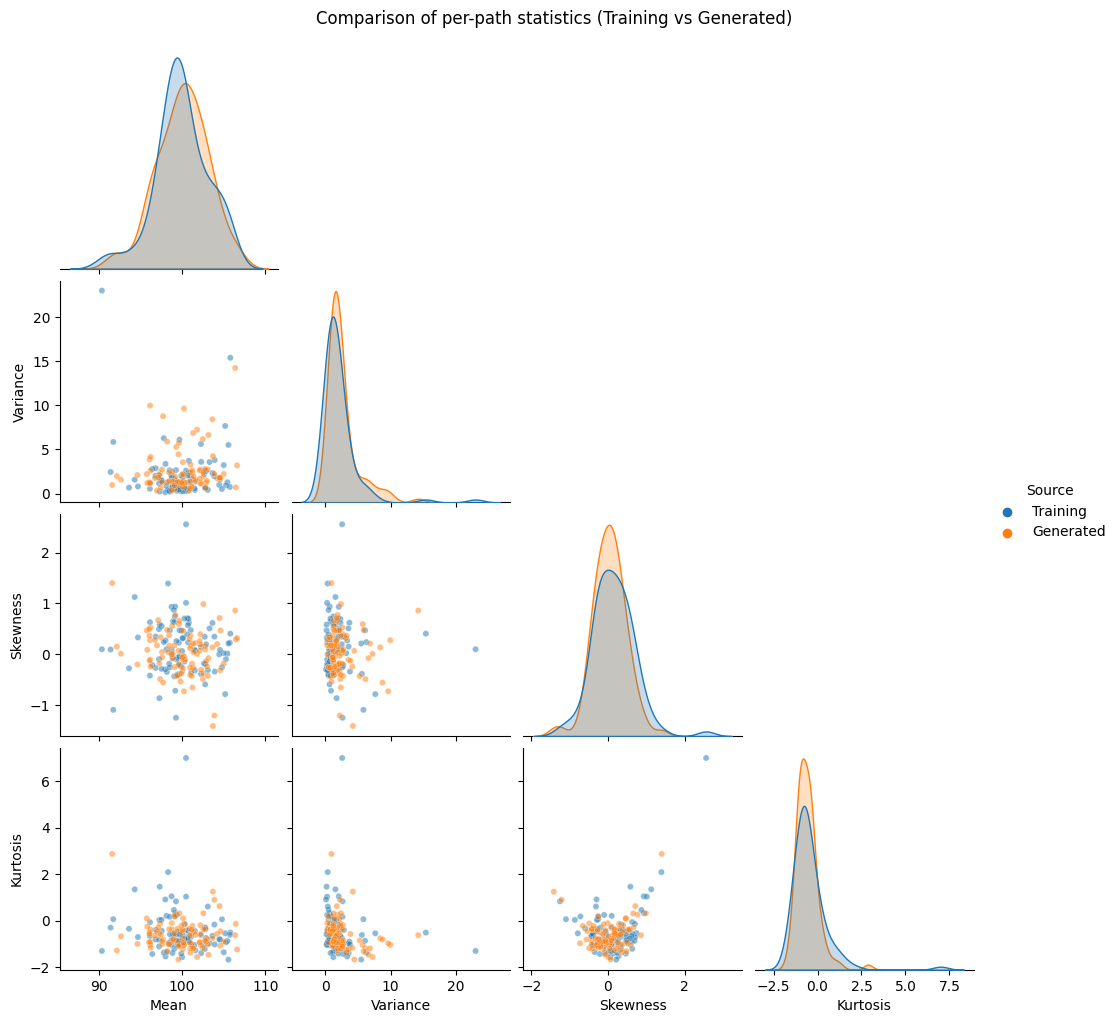

KS test on     Mean: statistic=0.135, p-value=0.395
KS test on Variance: statistic=0.270, p-value=0.003
KS test on Skewness: statistic=0.146, p-value=0.300
KS test on Kurtosis: statistic=0.112, p-value=0.631
Linear kernel MMD^2: 0.2955
RBF kernel MMD^2 = 4.9676e-03,  sigma = 2.895

=== Evaluating garch on prices ===


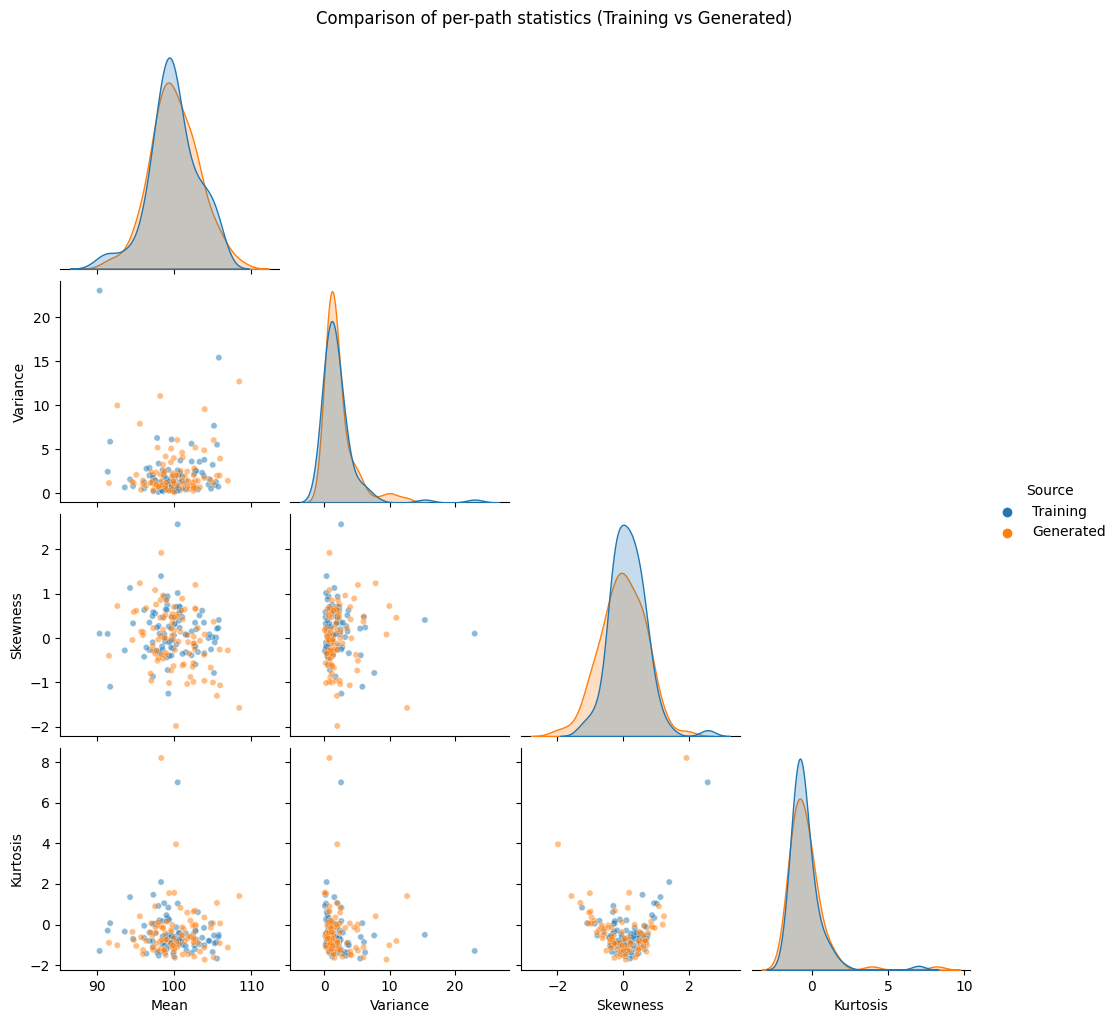

KS test on     Mean: statistic=0.090, p-value=0.868
KS test on Variance: statistic=0.135, p-value=0.395
KS test on Skewness: statistic=0.180, p-value=0.113
KS test on Kurtosis: statistic=0.112, p-value=0.631
Linear kernel MMD^2: 0.0841
RBF kernel MMD^2 = -4.1492e-03,  sigma = 2.905

Summary (log-returns):
      hist: MMD^2_lin=1.9129e+00, MMD^2_rbf=1.4045e-02, KS p-vals=[0.113, 0.868, 0.756, 0.022]
 bootstrap: MMD^2_lin=2.8061e+00, MMD^2_rbf=2.1006e-02, KS p-vals=[0.507, 0.002, 0.756, 0.022]
     truth: MMD^2_lin=0.0000e+00, MMD^2_rbf=-1.3380e-02, KS p-vals=[1.0, 1.0, 1.0, 1.0]
    hybrid: MMD^2_lin=1.2649e+01, MMD^2_rbf=5.5801e-02, KS p-vals=[0.395, 0.0, 0.113, 0.0]
       krr: MMD^2_lin=7.4392e+00, MMD^2_rbf=4.0416e-01, KS p-vals=[0.395, 0.0, 0.16, 0.0]
     arima: MMD^2_lin=8.3346e+00, MMD^2_rbf=4.9271e-01, KS p-vals=[0.868, 0.0, 0.078, 0.0]
     garch: MMD^2_lin=1.7639e+01, MMD^2_rbf=1.5739e-01, KS p-vals=[0.507, 0.868, 0.014, 0.0]

Summary (prices):
      hist: MMD^2_lin=1.4285e+0

In [25]:
res_log = evaluate_models(fut_prices, fut_logrets, gen_price, gen_logret, use="logret")
res_px  = evaluate_models(fut_prices, fut_logrets, gen_price, gen_logret, use="price")

print("\nSummary (log-returns):")
for k, v in res_log.items():
    print(f"{k:>10}: MMD^2_lin={v['mmd_linear']:.4e}, MMD^2_rbf={v['mmd_rbf']:.4e}, "
          f"KS p-vals={np.round(v['ks_pvals'],3).tolist()}")

print("\nSummary (prices):")
for k, v in res_px.items():
    print(f"{k:>10}: MMD^2_lin={v['mmd_linear']:.4e}, MMD^2_rbf={v['mmd_rbf']:.4e}, "
          f"KS p-vals={np.round(v['ks_pvals'],3).tolist()}")
